## testing file 

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [11]:
sentiment = pd.read_csv(r"fear_greed_index (1).csv")
trades = pd.read_csv(r"historical_data (1).csv")

In [14]:
print(sentiment.head())

print(trades.head())

print(sentiment.info())
print(trades.info())

print(sentiment.columns)
print(trades.columns)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [20]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

trades["date"] = trades["Timestamp IST"].dt.date

In [16]:
print("Sentiment Columns:")
print(sentiment.columns.tolist())

print("\nTrades Columns:")
print(trades.columns.tolist())

Sentiment Columns:
['timestamp', 'value', 'classification', 'date']

Trades Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [23]:
df = trades.merge(
    sentiment,
    on="date",
    how="left"
)

print("Shape:", df.shape)

print("\nClassification Counts:")
print(df["classification"].value_counts(dropna=False))

print("\nMerged Data:")
print(df.head())

Shape: (211224, 20)

Classification Counts:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

Merged Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98

In [24]:
print(df["classification"].isnull().sum())

6


In [27]:
print(df.shape)
print(df["classification"].value_counts(dropna=False))

(211218, 20)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [28]:
df = df.dropna(subset=["classification"]).reset_index(drop=True)

print(df.shape)

(211218, 20)


In [31]:
numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[numeric_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Execution Price  211218 non-null  float64
 1   Size Tokens      211218 non-null  float64
 2   Size USD         211218 non-null  float64
 3   Closed PnL       211218 non-null  float64
 4   Fee              211218 non-null  float64
dtypes: float64(5)
memory usage: 8.1 MB


In [32]:
print(df.describe())

       Execution Price   Size Tokens      Size USD  \
count    211218.000000  2.112180e+05  2.112180e+05   
mean      11415.047529  4.623341e+03  5.639192e+03   
min           0.000005  8.740000e-07  0.000000e+00   
25%           4.858550  2.940000e+00  1.937900e+02   
50%          18.280000  3.200000e+01  5.970200e+02   
75%         101.895000  1.878900e+02  2.058878e+03   
max      109004.000000  1.582244e+07  3.921431e+06   
std       29448.010305  1.042744e+05  3.657557e+04   

                    Timestamp IST  Start Position     Closed PnL  \
count                      211218    2.112180e+05  211218.000000   
mean   2025-01-31 12:08:21.724568   -2.994671e+04      48.549304   
min           2023-05-01 01:06:00   -1.433463e+07 -117990.104100   
25%           2024-12-31 21:53:45   -3.760725e+02       0.000000   
50%           2025-02-24 18:55:00    8.477051e+01       0.000000   
75%           2025-04-02 18:22:00    9.337697e+03       5.790132   
max           2025-05-01 12:13:00    

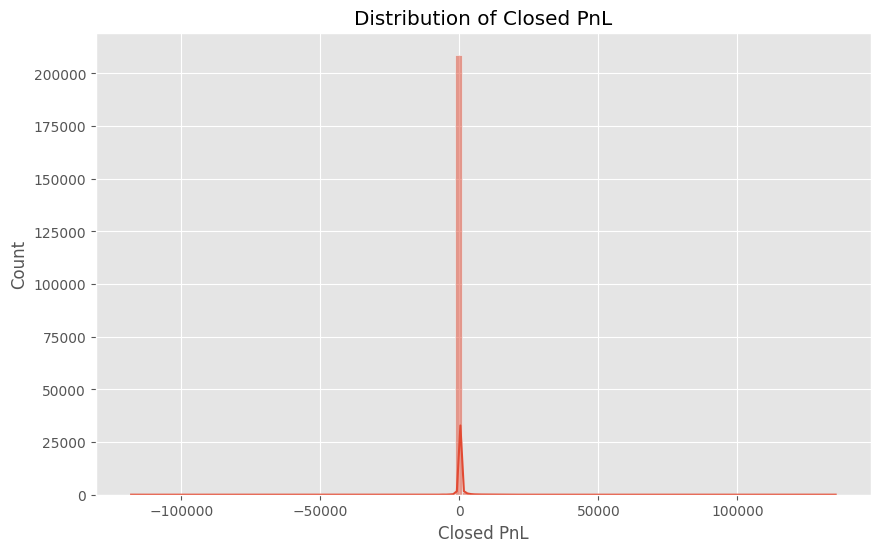

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    df["Closed PnL"],
    bins=100,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.show()

In [34]:
pnl_summary = df.groupby("classification")["Closed PnL"].agg(
    Trade_Count="count",
    Mean_PnL="mean",
    Median_PnL="median",
    Total_PnL="sum",
    Std_PnL="std"
)

print(pnl_summary)

                Trade_Count   Mean_PnL  Median_PnL     Total_PnL      Std_PnL
classification                                                               
Extreme Fear          21400  34.537862         0.0  7.391102e+05  1136.056091
Extreme Greed         39992  67.892861         0.0  2.715171e+06   766.828294
Fear                  61837  54.290400         0.0  3.357155e+06   935.355438
Greed                 50303  42.743559         0.0  2.150129e+06  1116.028390
Neutral               37686  34.307718         0.0  1.292921e+06   517.122220


In [35]:
size_summary = df.groupby("classification")["Size USD"].agg(
    Average_Size="mean",
    Median_Size="median",
    Maximum_Size="max"
)

print(size_summary)

                Average_Size  Median_Size  Maximum_Size
classification                                         
Extreme Fear     5349.731843      766.150    1120971.60
Extreme Greed    3112.251565      500.050     665771.71
Fear             7816.109931      735.960    3921430.72
Greed            5736.884375      555.000    2227114.71
Neutral          4782.732661      547.655    3641180.84


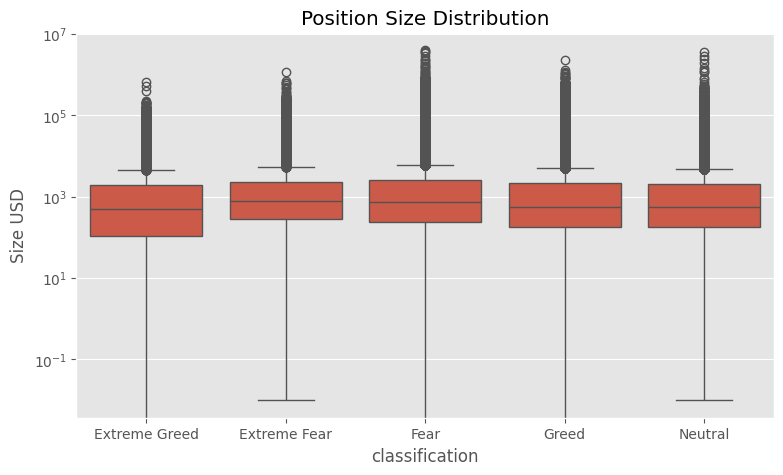

In [36]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="classification",
    y="Size USD"
)

plt.yscale("log")
plt.title("Position Size Distribution")
plt.show()

In [37]:
direction = pd.crosstab(
    df["classification"],
    df["Side"]
)

print(direction)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


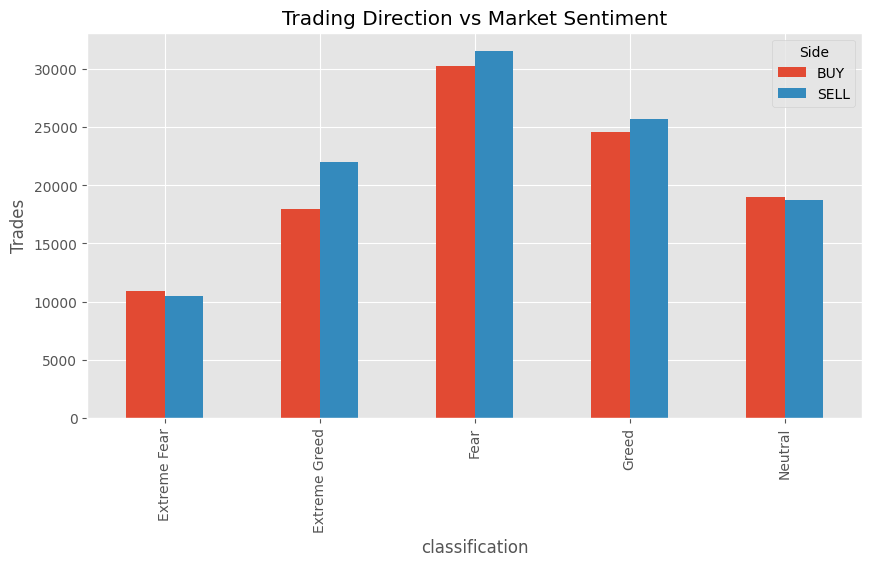

In [38]:
direction.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("Trades")
plt.title("Trading Direction vs Market Sentiment")
plt.show()

In [39]:
top_traders = (
    df.groupby("Account")["Closed PnL"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.265789e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.

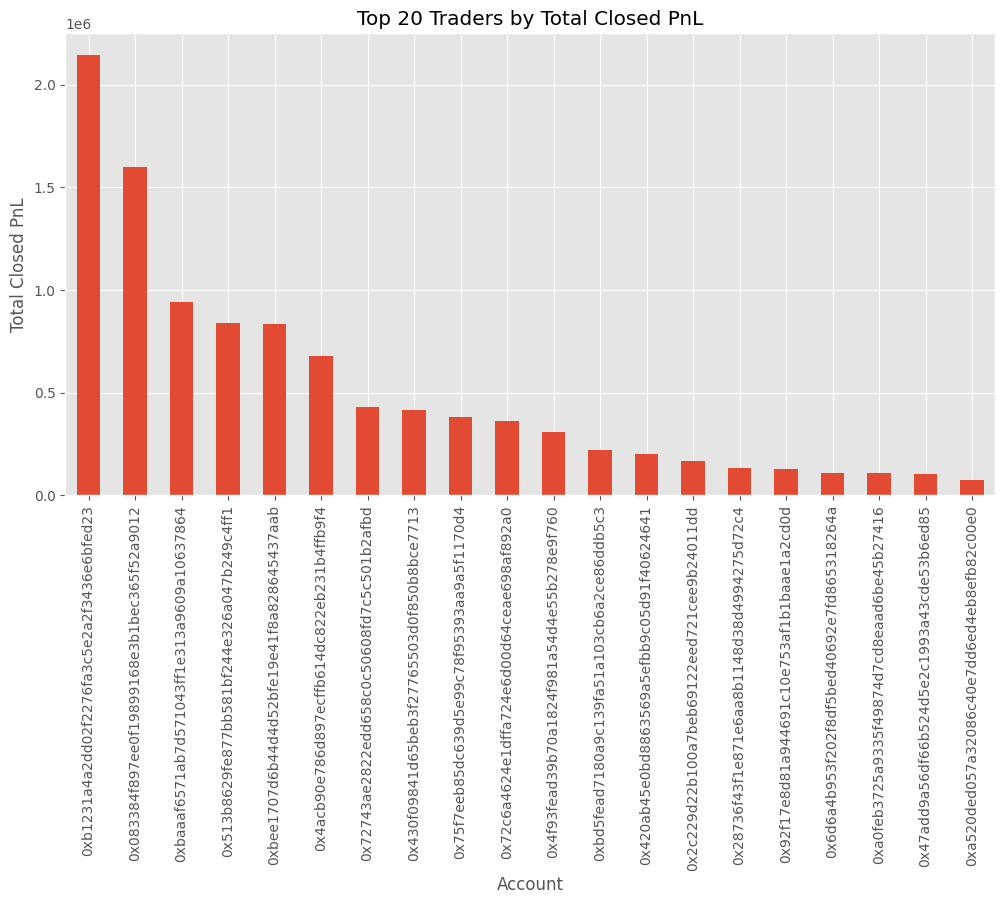

In [40]:
plt.figure(figsize=(12,6))

top_traders.plot(kind="bar")

plt.title("Top 20 Traders by Total Closed PnL")
plt.ylabel("Total Closed PnL")
plt.show()

In [41]:
trader_stats = (
    df.groupby("Account")
      .agg(
          Total_Trades=("Closed PnL","count"),
          Total_PnL=("Closed PnL","sum"),
          Average_PnL=("Closed PnL","mean"),
          Avg_Position=("Size USD","mean"),
          Total_Fees=("Fee","sum")
      )
      .sort_values("Total_PnL", ascending=False)
)

trader_stats.head()

,Total_Trades,Total_PnL,Average_PnL,Avg_Position,Total_Fees
Account,,,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,145.481748,3837.885375,15995.318252
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,16159.576734,7405.312304
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,44.364091,3210.472831,8596.705666
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,68.684419,34396.580284,76424.642892
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,20.806305,1844.211886,13352.899709


In [42]:
corr = df[
    [
        "Execution Price",
        "Size Tokens",
        "Size USD",
        "Closed PnL",
        "Fee"
    ]
].corr()

print(corr)

                 Execution Price  Size Tokens  Size USD  Closed PnL       Fee
Execution Price         1.000000    -0.017185  0.189859   -0.006429  0.225266
Size Tokens            -0.017185     1.000000  0.013310    0.005067  0.006710
Size USD                0.189859     0.013310  1.000000    0.123645  0.745940
Closed PnL             -0.006429     0.005067  0.123645    1.000000  0.084094
Fee                     0.225266     0.006710  0.745940    0.084094  1.000000


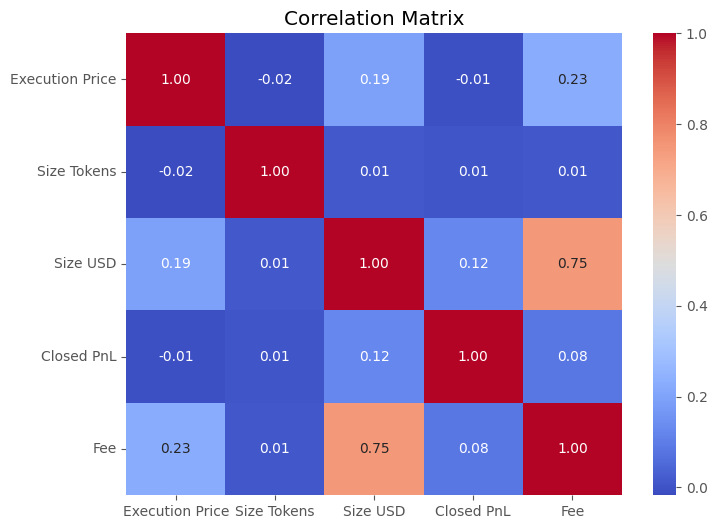

In [43]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [44]:
from scipy.stats import f_oneway

groups = [
    group["Closed PnL"].values
    for _, group in df.groupby("classification")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 9.062225672396462
P-value: 2.5753989847992047e-07
